In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
from torch import nn
from torch.autograd import Variable

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
print("Nombre GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detectada")



Usando dispositivo: cuda
Nombre GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
BASE_PATH = r"C:\Users\David\Documents\Master-Big-Data-Data-Sciencee-e-Inteligencia-Artificial\TFM\AeroGPT\data\CMAPSS"
RAW_PATH = os.path.join(BASE_PATH, "raw")
MODEL_PATH = os.path.join(BASE_PATH, "models_2")
FIG_PATH = os.path.join(BASE_PATH, "figures_2")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

FD_LIST = ["FD001", "FD002", "FD003", "FD004"]
WINDOW_SIZE = 30

FEATURE_COLS = ['setting_1','setting_2','setting_3'] + [f's_{i}' for i in range(1,22)]


CARGAR DATASHEET

In [3]:
def load_fd_dataset(fd):
    col_names = ['unit_nr','time_cycles','setting_1','setting_2','setting_3'] \
                + [f's_{i}' for i in range(1,22)]
    
    train_file = os.path.join(RAW_PATH, f"train_{fd}.txt")
    test_file  = os.path.join(RAW_PATH, f"test_{fd}.txt")
    rul_file   = os.path.join(RAW_PATH, f"RUL_{fd}.txt")

    train_df = pd.read_csv(train_file, sep='\s+', header=None, names=col_names)
    test_df  = pd.read_csv(test_file,  sep='\s+', header=None, names=col_names)
    rul_df   = pd.read_csv(rul_file,  sep='\s+', header=None, names=['RUL'])

    return train_df, test_df, rul_df


AÑADIR RUL

In [4]:
def add_rul(train_df):
    max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycles.columns = ['unit_nr','max_cycle']
    df = train_df.merge(max_cycles, on='unit_nr', how='left')
    df['RUL'] = df['max_cycle'] - df['time_cycles']
    return df.drop(columns=['max_cycle'])


QUITAR COLUMNAS SIN VARIANZA

In [5]:
def remove_zero_variance(df):
    variances = df.var()
    zero_var_cols = variances[variances == 0].index.tolist()
    print("Eliminando columnas sin varianza:", zero_var_cols)
    df = df.drop(columns=zero_var_cols)
    return df, zero_var_cols


ESCALADO Y QUITAR NAN

In [6]:
def scale_features(train_df, test_df, feature_cols):
    train_df[feature_cols] = train_df[feature_cols].fillna(train_df[feature_cols].mean())
    test_df[feature_cols]  = test_df[feature_cols].fillna(train_df[feature_cols].mean())

    scaler = StandardScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, test_df, scaler


SECUENCIAS ENTRENAMIENTO

In [7]:
def create_sequences(df, feature_cols, target_col, window_size=30):
    X, y = [], []
    for unit in df['unit_nr'].unique():
        unit_df = df[df['unit_nr']==unit].sort_values(by='time_cycles')
        features = unit_df[feature_cols].values
        targets = unit_df[target_col].values
        if len(unit_df) >= window_size:
            for i in range(len(unit_df) - window_size + 1):
                seq = features[i:i+window_size]
                if np.isnan(seq).any():
                    continue
                X.append(seq)
                y.append(targets[i+window_size-1])
    return np.array(X), np.array(y)


ULTIMA VENTANA TEST

In [8]:
def create_last_window_test(test_df, rul_df, feature_cols, window_size=30):
    X_test, y_test = [], []
    for i, unit in enumerate(test_df['unit_nr'].unique()):
        unit_df = test_df[test_df['unit_nr']==unit].sort_values(by='time_cycles')
        seq = unit_df[feature_cols].values
        
        if len(seq) < window_size:
            padding = np.zeros((window_size - len(seq), seq.shape[1]))
            seq = np.vstack([padding, seq])
        else:
            seq = seq[-window_size:]
        
        X_test.append(seq)
        y_test.append(rul_df.iloc[i,0])

    return np.array(X_test), np.array(y_test)


MODELO GRU

In [9]:
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim1=256, hidden_dim2=128, dropout=0.3):
        super(GRUModel, self).__init__()
        self.gru1 = nn.GRU(input_dim, hidden_dim1, num_layers=2, dropout=0.3, batch_first=True)
        self.gru2 = nn.GRU(hidden_dim1, hidden_dim2, num_layers=2, dropout=0.3, batch_first=True)
        self.linear = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        out,_ = self.gru1(x)
        out,_ = self.gru2(out)
        out = out[:,-1,:]
        out = self.linear(out)
        return out


ENTRENAMIENTO POR FD

In [ ]:
for fd in FD_LIST:

    print(f"\n==================== Procesando {fd} ====================\n")

    train_df, test_df, rul_df = load_fd_dataset(fd)
    train_df = add_rul(train_df)

    # Eliminar columnas sin varianza
    train_df, removed_cols = remove_zero_variance(train_df)
    test_df = test_df.drop(columns=removed_cols)

    # Escalar
    use_cols = [c for c in FEATURE_COLS if c not in removed_cols]
    train_df, test_df, scaler = scale_features(train_df, test_df, use_cols)

    # Secuencias
    X, y = create_sequences(train_df, use_cols, 'RUL', WINDOW_SIZE)

    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X)*0.8)
    train_idx, val_idx = indices[:split], indices[split:]
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)
    X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32).view(-1,1).to(device)

    print(f"{fd} -> Train: {X_train.shape}, Val: {X_val.shape}")

    # Modelo
    model = GRUModel(len(use_cols)).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

    best_val_loss = np.inf
    patience = 30
    wait = 0
    n_epochs = 500
    batch_size = 32

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(X_train_tensor.size(0))
        epoch_loss = 0

        for i in range(0, X_train_tensor.size(0), batch_size):
            idx = perm[i:i+batch_size]
            batch_x = X_train_tensor[idx]
            batch_y = y_train_tensor[idx]

            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_x)

        epoch_loss /= len(X_train_tensor)
        train_losses.append(epoch_loss)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor).item()
            val_losses.append(val_loss)
            val_mae = mean_absolute_error(y_val_tensor.cpu(), val_pred.cpu())
            val_rmse = np.sqrt(val_loss)

        scheduler.step(val_loss)

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{n_epochs} -> Train {epoch_loss:.4f}, Val {val_loss:.4f}, MAE {val_mae:.4f}, RMSE {val_rmse:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, f'best_model_{fd}.pth'))
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping")
                break

    joblib.dump(scaler, os.path.join(MODEL_PATH, f'scaler_{fd}.pkl'))



==================== Procesando FD001 ====================

Eliminando columnas sin varianza: ['setting_3', 's_1', 's_10', 's_18', 's_19']
FD001 -> Train: (14184, 30, 19), Val: (3547, 30, 19)
Epoch 1/500 -> Train 8032.3754, Val 5321.5859, MAE 55.8983, RMSE 72.9492
Epoch 10/500 -> Train 638.6049, Val 529.4354, MAE 14.2566, RMSE 23.0095
Epoch 20/500 -> Train 40.0579, Val 41.0266, MAE 4.1825, RMSE 6.4052
Epoch 30/500 -> Train 13.1497, Val 14.3674, MAE 2.6751, RMSE 3.7904
Epoch 40/500 -> Train 18.0531, Val 7.8093, MAE 1.9925, RMSE 2.7945
Epoch 50/500 -> Train 5.9235, Val 9.0134, MAE 2.2644, RMSE 3.0022
Epoch 60/500 -> Train 3.9206, Val 3.6907, MAE 1.4152, RMSE 1.9211
Epoch 70/500 -> Train 4.0360, Val 4.4822, MAE 1.5999, RMSE 2.1171
Epoch 80/500 -> Train 2.6831, Val 2.4017, MAE 1.1412, RMSE 1.5498
Epoch 90/500 -> Train 23.8144, Val 7.5728, MAE 1.8535, RMSE 2.7519
Epoch 100/500 -> Train 1.9288, Val 1.9687, MAE 0.9848, RMSE 1.4031
Epoch 110/500 -> Train 1.5077, Val 1.5980, MAE 0.9267, RMSE 1

EVALUACION TEST


===== TEST FD001 =====
Eliminando columnas sin varianza: ['setting_3', 's_1', 's_10', 's_18', 's_19']


C:\Users\David\AppData\Local\Temp\ipykernel_25276\3808591063.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(MODEL_PATH, f

FD001 -> MSE=945.14, MAE=22.39, RMSE=30.74


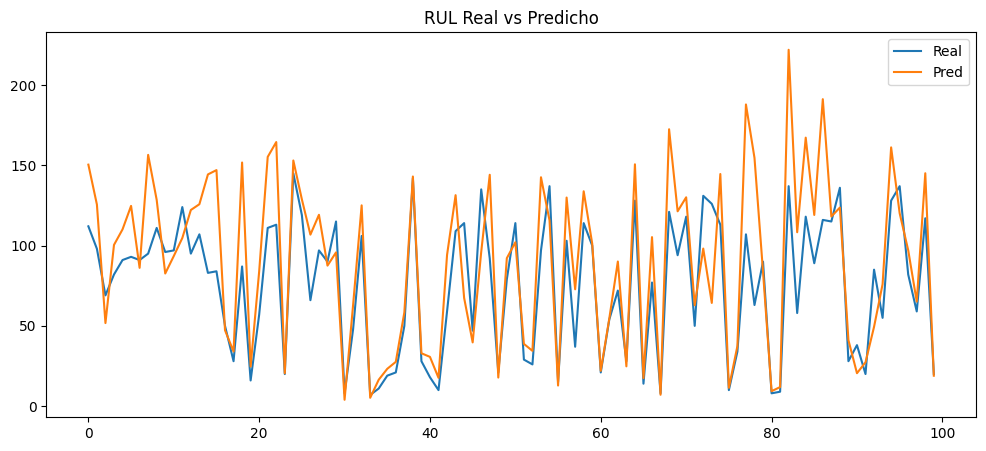


===== TEST FD002 =====
Eliminando columnas sin varianza: []


C:\Users\David\AppData\Local\Temp\ipykernel_25276\3808591063.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(MODEL_PATH, f

FD002 -> MSE=1288.73, MAE=25.37, RMSE=35.90


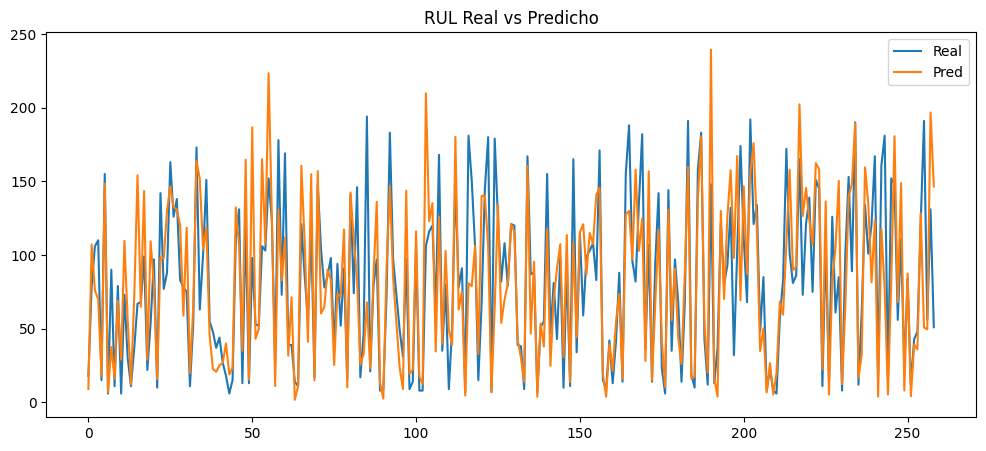


===== TEST FD003 =====
Eliminando columnas sin varianza: ['setting_3', 's_1', 's_18', 's_19']
FD003 -> MSE=1747.45, MAE=25.60, RMSE=41.80


C:\Users\David\AppData\Local\Temp\ipykernel_25276\3808591063.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(MODEL_PATH, f

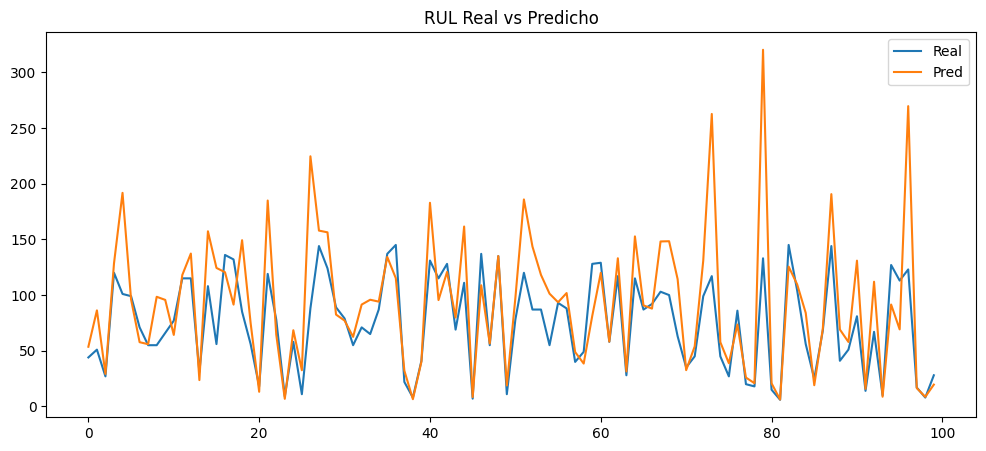


===== TEST FD004 =====
Eliminando columnas sin varianza: []


C:\Users\David\AppData\Local\Temp\ipykernel_25276\3808591063.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(MODEL_PATH, f

FD004 -> MSE=2163.32, MAE=32.62, RMSE=46.51


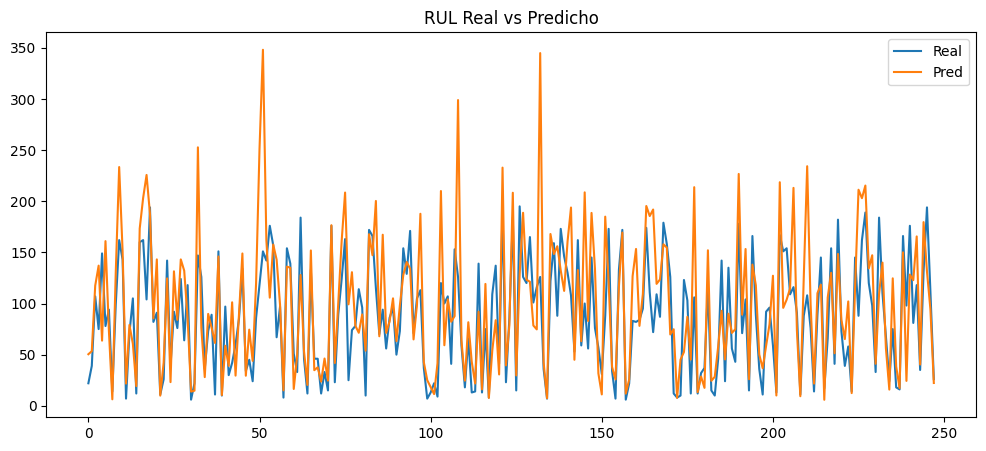

In [15]:
# Test final para cada FD
for fd in FD_LIST:

    print(f"\n===== TEST {fd} =====")

    train_df, test_df, rul_df = load_fd_dataset(fd)
    train_df, removed_cols = remove_zero_variance(train_df)

    use_cols = [c for c in FEATURE_COLS if c not in removed_cols]

    scaler = joblib.load(os.path.join(MODEL_PATH, f'scaler_{fd}.pkl'))

    test_df[use_cols] = test_df[use_cols].fillna(train_df[use_cols].mean())
    test_df[use_cols] = scaler.transform(test_df[use_cols])

    X_test, y_test = create_last_window_test(test_df, rul_df, use_cols, WINDOW_SIZE)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1,1).to(device)

    model = GRUModel(len(use_cols)).to(device)
    model.load_state_dict(torch.load(os.path.join(MODEL_PATH, f'best_model_{fd}.pth')))
    model.eval()

    with torch.no_grad():
        y_pred = model(X_test_tensor)

    mse = criterion(y_pred, y_test_tensor).item()
    mae = mean_absolute_error(y_test_tensor.cpu(), y_pred.cpu())
    rmse = np.sqrt(mse)

    print(f"{fd} -> MSE={mse:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test, label='Real')
    plt.plot(y_pred.cpu().numpy(), label='Pred')
    plt.title("RUL Real vs Predicho")
    plt.legend()
    plt.show()


GRÁFICAS

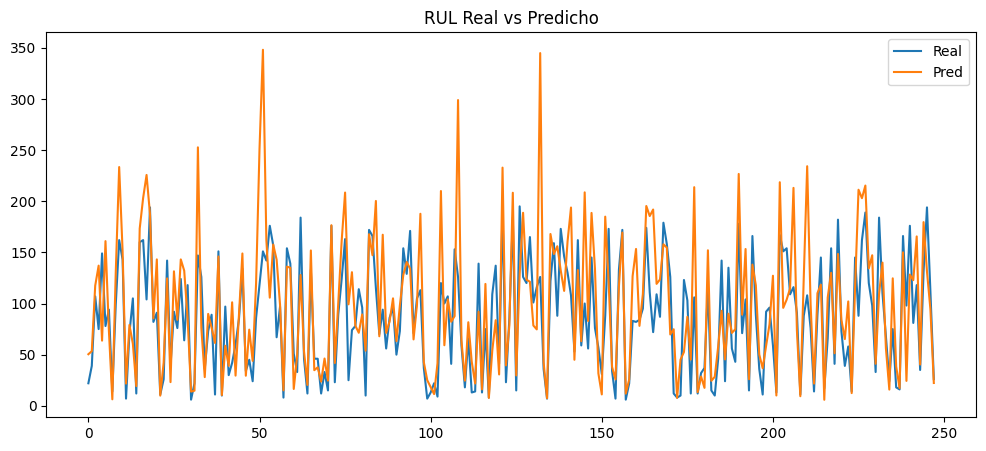

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Real')
plt.plot(y_pred.cpu().numpy(), label='Pred')
plt.title("RUL Real vs Predicho")
plt.legend()
plt.show()
